# Classification Modeling and Assumption Evaluation in Financial and Health Datasets

# Executive Summary
This assignment evaluated classification methods across two tasks. Logistic regression theory was demonstrated by showing the equivalence of the logistic and logit forms. Multiple classifiers were then compared on the ISLP Weekly dataset to predict market Direction using both the full feature set and a 1990–2008 training split with 2009–2010 holdout testing. Finally, four multi-class models were developed for the Kaggle obesity-risk dataset using consistent preprocessing and comparative evaluation. Across both datasets, results showed that predictive signal and appropriate assumptions matter more than model complexity, and that simpler models can perform competitively when signal strength is limited.

## Key Insights
-   On the Weekly dataset, the predictive signal was weak. Lag2 was the only statistically significant predictor in the full logistic regression, and logistic regression (Lag2) and LDA (Lag2) achieved the best holdout accuracy at 62.5%, with stronger identification of “Up” weeks than “Down” weeks.

-   Increasing complexity on the weekly did not improve results. QDA and Naive Bayes performed slightly worse than linear classifiers, while KNN (k = 1) performed near chance, indicating limited benefit from nonlinear flexibility.

-   For the Kaggle obesity-risk task, four complementary frameworks were implemented: regularized multinomial logistic regression, LDA, Naive Bayes, and an RBF SVM. Results emphasized disciplined preprocessing, model comparison, and the balance between interpretability and flexibility for multi-class classification.

# Questions from ISLP

## Question 1. Using a little bit of algebra, prove that (4.2) is equivalent to (4.3). In other words, the logistic function representation and logit representation for the logistic regression model are equivalent.

Let $\eta = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$.

(4.2) logistic form:

$p(x) = P(Y=1\mid X=x) = \frac{e^\eta}{1 + e^\eta}$.

Compute odds:
$ \frac{p(x)}{1-p(x)} = \frac{\frac{e^\eta}{1+e^\eta}}{1 - \frac{e^\eta}{1+e^\eta}} = \frac{\frac{e^\eta}{1+e^\eta}}{\frac{1+e^\eta - e^\eta}{1+e^\eta}} = \frac{\frac{e^\eta}{1+e^\eta}}{\frac{1}{1+e^\eta}} = e^\eta$.

The the log on both sides of the equation:

$\log\left(\frac{p(x)}{1-p(x)}\right) = \log(e^\eta) = \eta = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$ <-- (4.3) logit form

So starting from (4.3)

$\log\left(\frac{p}{1-p}\right)=\eta \Rightarrow \frac{p}{1-p}=e^\eta \Rightarrow p = e^\eta(1-p) \Rightarrow p + pe^\eta = e^\eta \Rightarrow p(1+e^\eta)=e^\eta \Rightarrow p = \frac{e^\eta}{1+e^\eta}$

It finishes with the (4.2) logistic form, thus they are equivalent.

## Question 13. This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter’s lab, except that it contains 1,089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ---- Load ISLP package) ----
from ISLP import load_data
Weekly = load_data("Weekly")  # DataFrame

Weekly.head(), Weekly.shape

weekly_desc = Weekly.describe().T.reset_index().rename(columns={"index":"Variable"})

direction_counts = Weekly["Direction"].value_counts().reset_index()
direction_counts.columns = ["Direction", "Count"]

### (a) Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

The Weekly data consist of 1,089 observations from 1990 to 2010. The response variable, Direction, is reasonably balanced, with 605 “Up” weeks and 484 “Down” weeks, indicating no severe class imbalance. The correlation heatmap shows that correlations among the lag variables (Lag1–Lag5) are generally weak, and none exhibit strong linear relationships with Today. The pairwise scatterplots likewise show substantial overlap between “Up” and “Down” weeks, suggesting that separation between classes is subtle. However, trading Volume displays a clear upward trend over time, increasing steadily from 1990 through 2010, while weekly returns (Today) fluctuate around zero with no obvious long-term trend. Overall, any predictive signal appears modest, with at most a slight association in certain lag variables (particularly Lag2), but no strong or visually obvious patterns.

               Year         Lag1         Lag2         Lag3         Lag4  \
count   1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean    2000.048669     0.150585     0.151079     0.147205     0.145818   
std        6.033182     2.357013     2.357254     2.360502     2.360279   
min     1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%     1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%     2000.000000     0.241000     0.241000     0.241000     0.238000   
75%     2005.000000     1.405000     1.409000     1.409000     1.409000   
max     2010.000000    12.026000    12.026000    12.026000    12.026000   

               Lag5       Volume        Today Direction  
count   1089.000000  1089.000000  1089.00

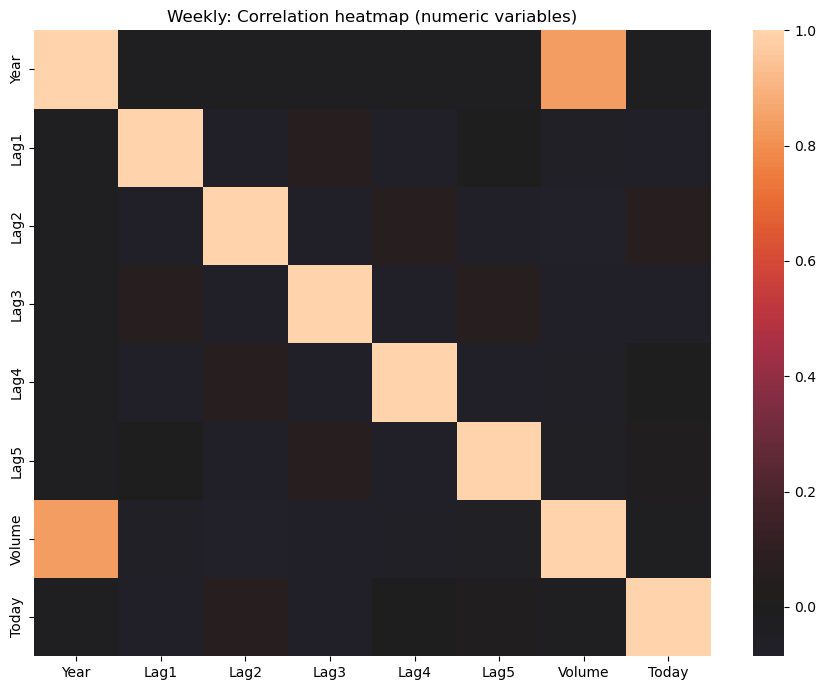

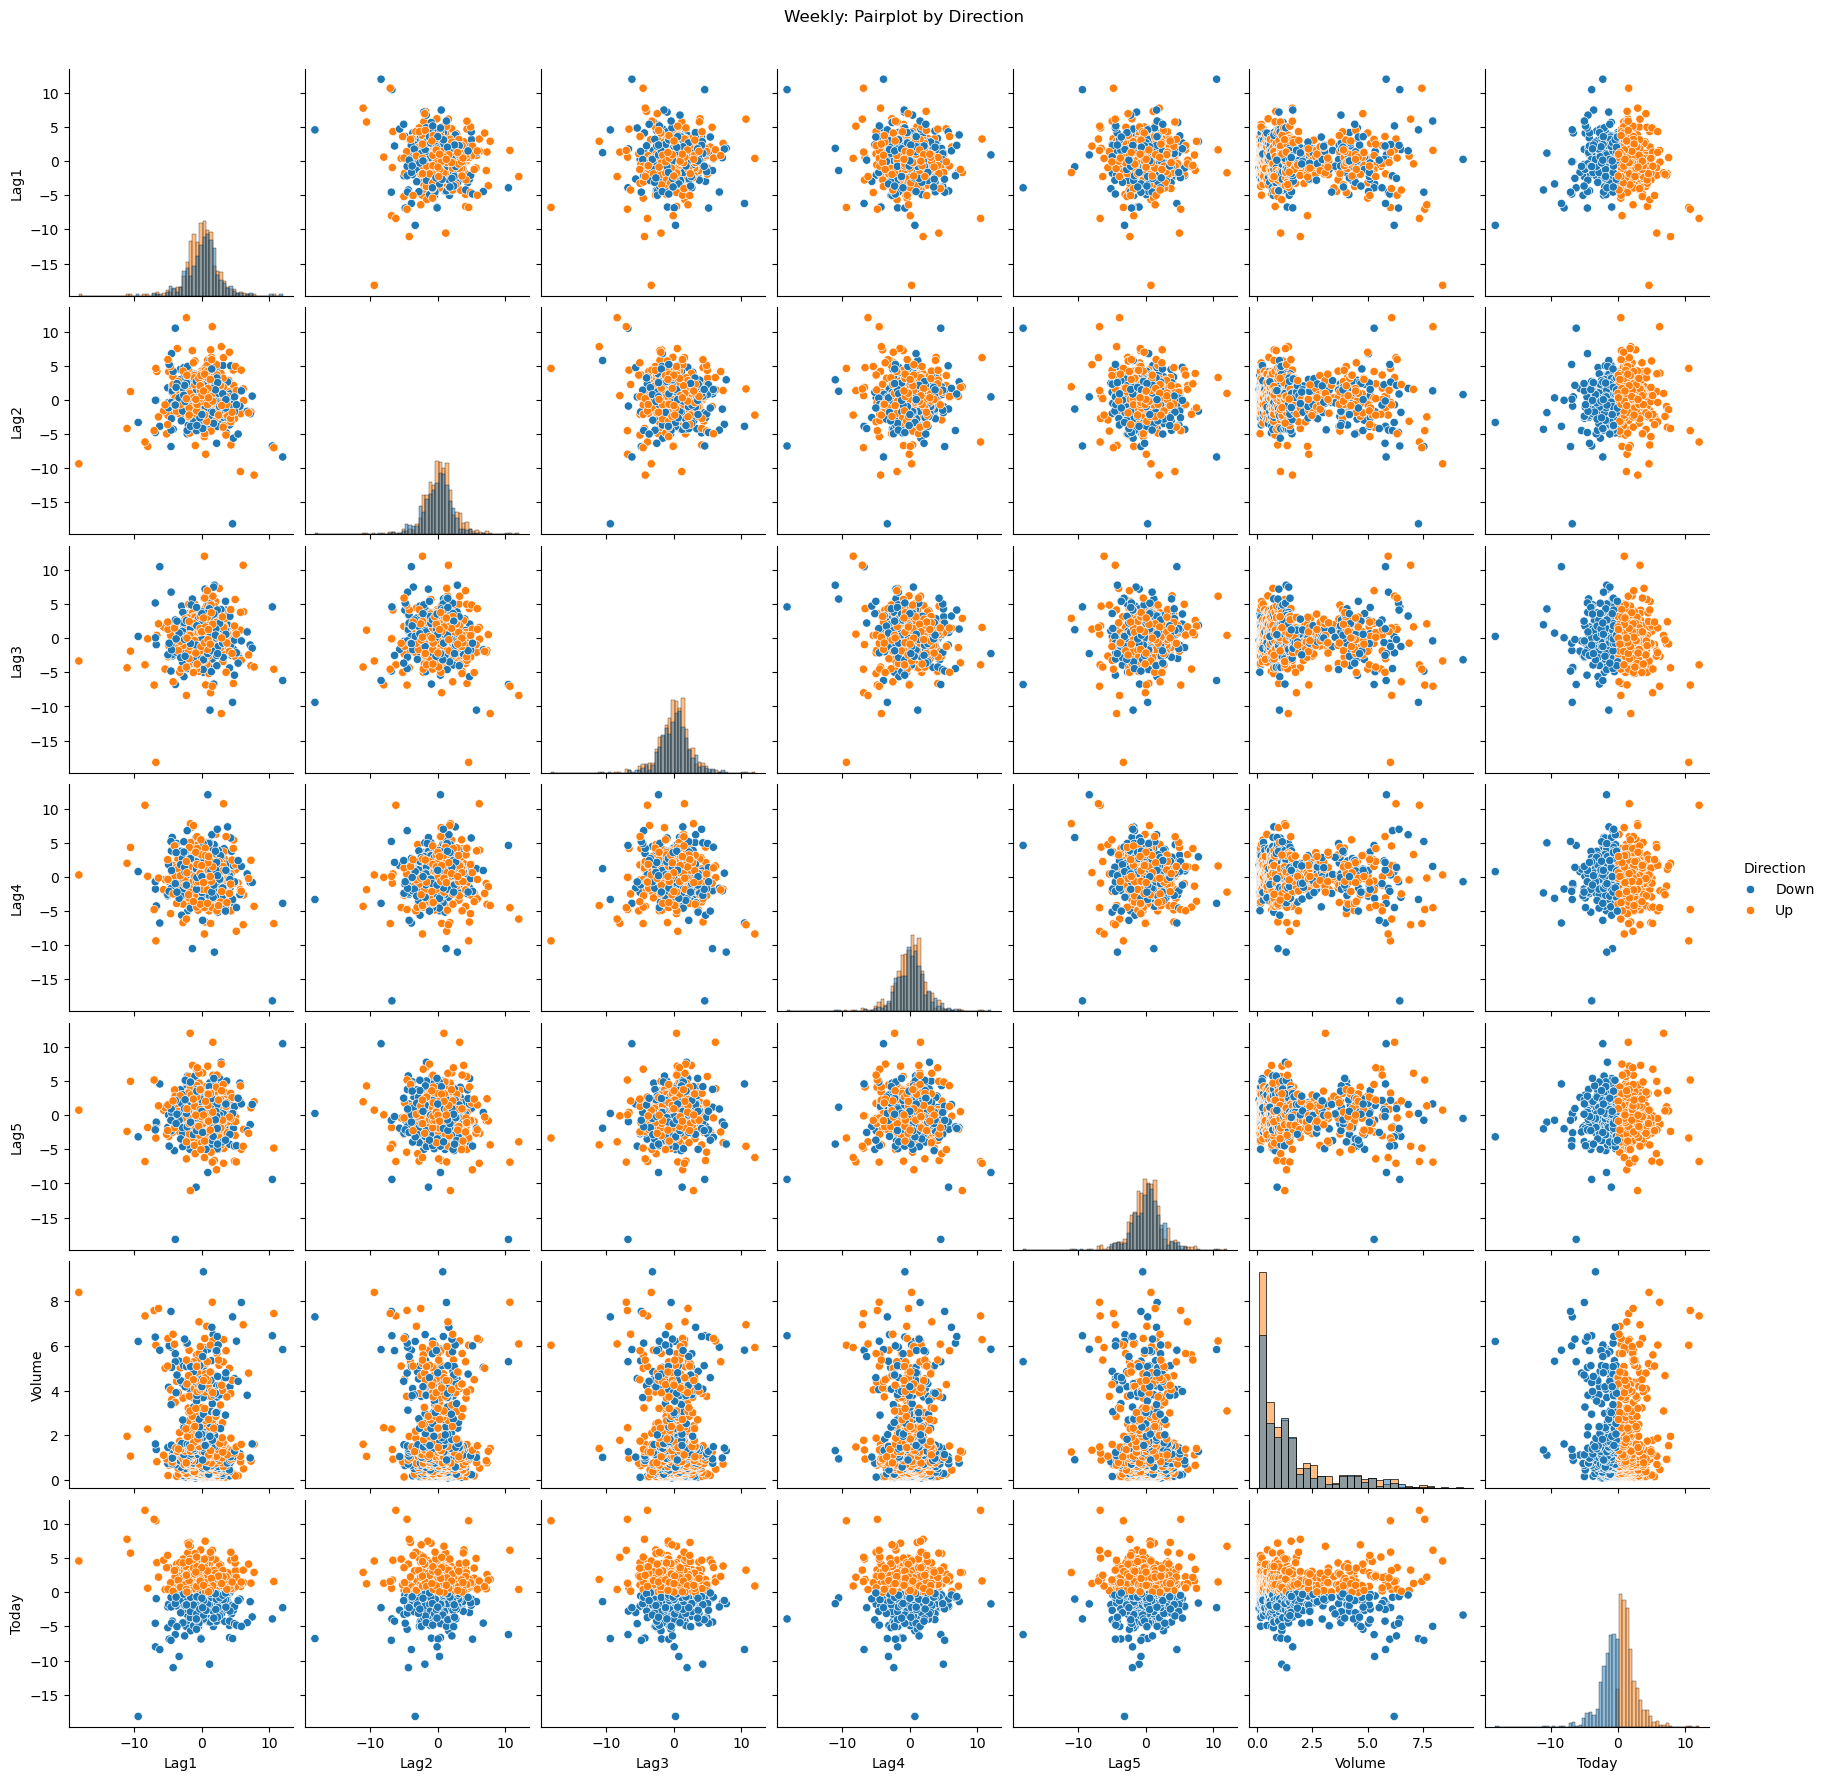

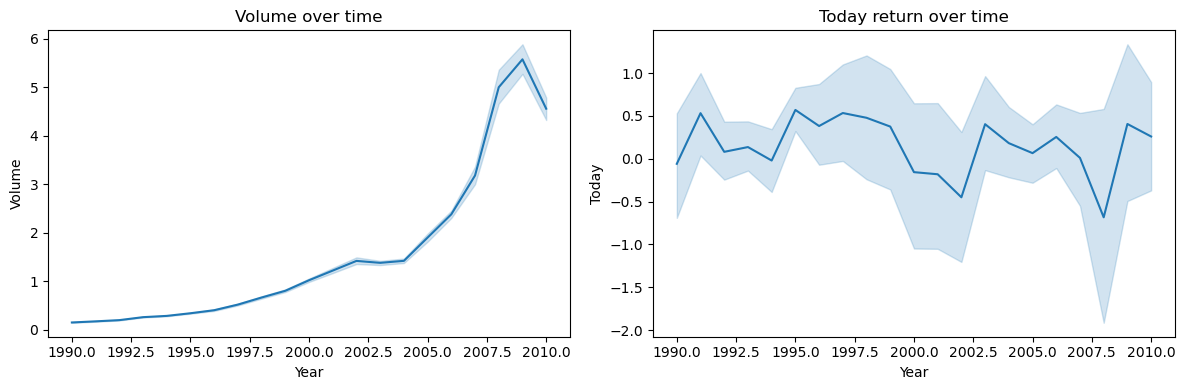

In [5]:
# Basic summaries
print(Weekly.describe(include="all"))

print("\nDirection counts:")
print(Weekly["Direction"].value_counts())

# Correlation among numeric variables
num_cols = ["Year","Lag1","Lag2","Lag3","Lag4","Lag5","Volume","Today"]
corr = Weekly[num_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=False, center=0)
plt.title("Weekly: Correlation heatmap (numeric variables)")
plt.tight_layout()
plt.show()

# Pairplot (subset to keep it readable)
sns.pairplot(Weekly[["Lag1","Lag2","Lag3","Lag4","Lag5","Volume","Today","Direction"]],
             hue="Direction", diag_kind="hist")
plt.suptitle("Weekly: Pairplot by Direction", y=1.02)
plt.show()

# Time trend: Volume and Today vs Year
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.lineplot(data=Weekly, x="Year", y="Volume", ax=ax[0])
ax[0].set_title("Volume over time")
sns.lineplot(data=Weekly, x="Year", y="Today", ax=ax[1])
ax[1].set_title("Today return over time")
plt.tight_layout()
plt.show()

### (b) Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

Using the full data set, a logistic regression model was fit with
Direction as the response and Lag1–Lag5 and Volume as predictors. The model results indicate that Lag2 is the only predictor that is statistically significant at the 5% level (p = 0.030). Its positive coefficient (0.0584) suggests that higher returns two weeks prior are associated with an increased probability of an “Up” week. All other lag variables (Lag1, Lag3, Lag4, and Lag5) and Volume have p-values well above 0.05, indicating no statistically significant relationship with Direction in this model. The pseudo $R^2$ value is very small (≈ 0.009), suggesting that overall explanatory power is limited. Thus, while Lag2 shows a modest statistical association, the predictive signal in the full model appears weak.

In [6]:
def eval_binary_from_proba(y_true_updown, proba_up, threshold=0.5):
    """
    y_true_updown: Series with values 'Up'/'Down'
    proba_up: predicted P(Up)
    """
    y_pred = np.where(proba_up >= threshold, "Up", "Down")
    cm = confusion_matrix(y_true_updown, y_pred, labels=["Down","Up"])
    acc = accuracy_score(y_true_updown, y_pred)
    return cm, acc
  
Weekly2 = Weekly.copy()
Weekly2["Direction_bin"] = (Weekly2["Direction"] == "Up").astype(int)

model_full = smf.glm(
    "Direction_bin ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume",
    data=Weekly2,
    family=sm.families.Binomial()
).fit()

print(model_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Direction_bin   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Sat, 28 Feb 2026   Deviance:                       1486.4
Time:                        19:48:28   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2669      0.086      3.106      0.0

### (c) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

The confusion matrix for the full logistic regression model shows 54 correctly predicted “Down” weeks and 557 correctly predicted “Up” weeks, yielding an overall accuracy of approximately 56.1%. However, the model misclassifies 430 “Down” weeks as “Up,” while only 48 “Up” weeks are misclassified as “Down.” This indicates that the model has a strong tendency to predict “Up,” resulting in many false positives (predicting Up when the market actually went Down). In other words, logistic regression correctly identifies most Up weeks but performs poorly in detecting Down weeks. The relatively modest overall accuracy, only slightly above random guessing for a balanced binary outcome, further suggests that the predictive power of the lag variables and Volume is limited.

In [7]:
proba_full_up = model_full.predict(Weekly2)  # predicts P(Direction_bin=1) = P(Up)
cm_full, acc_full = eval_binary_from_proba(Weekly2["Direction"], proba_full_up)
print("Confusion matrix [rows=true Down/Up, cols=pred Down/Up]:\n", cm_full)
print("Overall accuracy:", acc_full)

Confusion matrix [rows=true Down/Up, cols=pred Down/Up]:
 [[ 54 430]
 [ 48 557]]
Overall accuracy: 0.5610651974288338


### (d) Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [8]:
train = Weekly2[Weekly2["Year"] <= 2008].copy()
test  = Weekly2[Weekly2["Year"] >= 2009].copy()

X_train_lag2 = train[["Lag2"]].values
X_test_lag2  = test[["Lag2"]].values

y_train = train["Direction"].values
y_test  = test["Direction"].values

y_train_bin = (train["Direction"] == "Up").astype(int).values
y_test_bin  = (test["Direction"] == "Up").astype(int).values

train.shape, test.shape

model_lag2 = smf.glm(
    "Direction_bin ~ Lag2",
    data=train,
    family=sm.families.Binomial()
).fit()

print(model_lag2.summary())

proba_test_up = model_lag2.predict(test)
cm_logit, acc_logit = eval_binary_from_proba(test["Direction"], proba_test_up)
print("Logit(Lag2) CM:\n", cm_logit)
print("Logit(Lag2) accuracy:", acc_logit)

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Direction_bin   No. Observations:                  985
Model:                            GLM   Df Residuals:                      983
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -675.27
Date:                Sat, 28 Feb 2026   Deviance:                       1350.5
Time:                        19:49:53   Pearson chi2:                     985.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.004221
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2033      0.064      3.162      0.0

### (e) Repeat (d) using LDA.

In [9]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_lag2, y_train)
proba_lda_up = lda.predict_proba(X_test_lag2)[:, list(lda.classes_).index("Up")]

cm_lda, acc_lda = eval_binary_from_proba(pd.Series(y_test), proba_lda_up)
print("LDA CM:\n", cm_lda)
print("LDA accuracy:", acc_lda)

LDA CM:
 [[ 9 34]
 [ 5 56]]
LDA accuracy: 0.625


### (f) Repeat (d) using QDA.

In [11]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_lag2, y_train)
proba_qda_up = qda.predict_proba(X_test_lag2)[:, list(qda.classes_).index("Up")]

cm_qda, acc_qda = eval_binary_from_proba(pd.Series(y_test), proba_qda_up)
print("QDA CM:\n", cm_qda)
print("QDA accuracy:", acc_qda)

QDA CM:
 [[ 0 43]
 [ 0 61]]
QDA accuracy: 0.5865384615384616


### (g) Repeat (d) using KNN with K = 1.

In [12]:
# Define and fit
knn1 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=1))
])
knn1.fit(X_train_lag2, y_train)

# Identify the index for "Up" safely
target_class = "Up"
classes = knn1.named_steps['knn'].classes_
up_idx = np.where(classes == target_class)[0][0]

# Predict probabilities
proba_knn_up = knn1.predict_proba(X_test_lag2)[:, up_idx]

# Evaluate
cm_knn, acc_knn = eval_binary_from_proba(pd.Series(y_test), proba_knn_up)

print(f"KNN(k=1) CM:\n{cm_knn}")
print(f"KNN(k=1) accuracy: {acc_knn:.4f}")

KNN(k=1) CM:
[[21 22]
 [30 31]]
KNN(k=1) accuracy: 0.5000


### (h) Repeat (d) using naive Bayes.

In [13]:
nb = GaussianNB()
nb.fit(X_train_lag2, y_train)
proba_nb_up = nb.predict_proba(X_test_lag2)[:, list(nb.classes_).index("Up")]

cm_nb, acc_nb = eval_binary_from_proba(pd.Series(y_test), proba_nb_up)
print("Naive Bayes CM:\n", cm_nb)
print("Naive Bayes accuracy:", acc_nb)

Naive Bayes CM:
 [[ 0 43]
 [ 0 61]]
Naive Bayes accuracy: 0.5865384615384616


### (i) Which of these methods appears to provide the best results on this data?
Among the methods evaluated on the 2009–2010 holdout period, logistic regression with Lag2 as the sole predictor and LDA (also using Lag2) produced the best performance, each achieving an accuracy of 62.5%. Both methods generated identical confusion matrices, correctly predicting 56 of 61 “Up” weeks and 9 of 43 “Down” weeks. QDA and naive Bayes performed slightly worse, with accuracies of approximately 58.7%, while KNN (k = 1) performed poorest at 50%, essentially equivalent to random guessing. Overall, the linear classifiers (logistic regression and LDA) appear to provide the strongest predictive performance on this data, though the improvement over chance remains modest, indicating that the lag variables contain only limited predictive signal.

In [14]:
results_i = pd.DataFrame({
    "Method": ["Logit(Lag2)", "LDA(Lag2)", "QDA(Lag2)", "KNN(k=1)", "Naive Bayes"],
    "Accuracy": [acc_logit, acc_lda, acc_qda, acc_knn, acc_nb]
}).sort_values("Accuracy", ascending=False)

results_i

,Method,Accuracy
0,Logit(Lag2),0.625000
1,LDA(Lag2),0.625000
2,QDA(Lag2),0.586538
4,Naive Bayes,0.586538
3,KNN(k=1),0.500000


### (j) Experiment with different combinations of predictors, including possible transformations and interactions, for each of themethods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.

To further evaluate model performance, multiple combinations of
predictors, interactions, and values of K for KNN were examined using the 2009–2010 holdout period. Across all specifications tested, the best-performing model was logistic regression using Lag2 as the sole predictor, which achieved an accuracy of 62.5%. The associated confusion matrix was:

$\frac{9\ \&\ 34}{5\ \&\ 56}$

indicating that the model correctly classified 56 of 61 “Up” weeks and 9 of 43 “Down” weeks. Expanding the model to include additional lag variables, interactions, or Volume did not improve out-of-sample performance. Similarly, tuning K in KNN failed to outperform the simpler linear classifiers. Overall, these results suggest that Lag2 contains the strongest predictive signal in the data, but the signal remains modest, and increasing model complexity does not meaningfully improve classification accuracy.

In [15]:
from itertools import combinations

predictors = ["Lag1","Lag2","Lag3","Lag4","Lag5","Volume"]
K_list = [1,3,5,7,9,15]

def get_X(df, cols):
    return df[cols].values

def try_logit(cols, formula_extra=""):
    # formula like Direction_bin ~ Lag2 + Lag3 or with interactions
    rhs = " + ".join(cols)
    if formula_extra:
        rhs = rhs + " + " + formula_extra
    m = smf.glm(f"Direction_bin ~ {rhs}", data=train, family=sm.families.Binomial()).fit()
    proba = m.predict(test)
    cm, acc = eval_binary_from_proba(test["Direction"], proba)
    return acc, cm, m

def try_lda(cols):
    clf = LinearDiscriminantAnalysis()
    clf.fit(get_X(train, cols), y_train)
    proba = clf.predict_proba(get_X(test, cols))[:, list(clf.classes_).index("Up")]
    cm, acc = eval_binary_from_proba(pd.Series(y_test), proba)
    return acc, cm, clf

def try_qda(cols):
    clf = QuadraticDiscriminantAnalysis()
    clf.fit(get_X(train, cols), y_train)
    proba = clf.predict_proba(get_X(test, cols))[:, list(clf.classes_).index("Up")]
    cm, acc = eval_binary_from_proba(pd.Series(y_test), proba)
    return acc, cm, clf

def try_nb(cols):
    clf = GaussianNB()
    clf.fit(get_X(train, cols), y_train)
    proba = clf.predict_proba(get_X(test, cols))[:, list(clf.classes_).index("Up")]
    cm, acc = eval_binary_from_proba(pd.Series(y_test), proba)
    return acc, cm, clf

def try_knn(cols, k):
    clf = Pipeline([("scaler", StandardScaler()),
                    ("knn", KNeighborsClassifier(n_neighbors=k))])
    clf.fit(get_X(train, cols), y_train)
    proba = clf.predict_proba(get_X(test, cols))[:, list(clf.classes_).index("Up")]
    cm, acc = eval_binary_from_proba(pd.Series(y_test), proba)
    return acc, cm, clf

# Candidate feature sets: all singletons + selected pairs + full set
feature_sets = [[c] for c in predictors] + [list(s) for s in combinations(predictors, 2)] + [predictors]

records = []

# Logistic / LDA / QDA / NB over feature sets
for cols in feature_sets:
    acc, cm, _ = try_logit(cols)
    records.append(("Logit", cols, None, acc, cm))
    acc, cm, _ = try_lda(cols)
    records.append(("LDA", cols, None, acc, cm))
    acc, cm, _ = try_qda(cols)
    records.append(("QDA", cols, None, acc, cm))
    acc, cm, _ = try_nb(cols)
    records.append(("NaiveBayes", cols, None, acc, cm))

# KNN over feature sets + K
for cols in feature_sets:
    for k in K_list:
        acc, cm, _ = try_knn(cols, k)
        records.append(("KNN", cols, k, acc, cm))

# One interaction example in logistic regression
acc, cm, _ = try_logit(["Lag2","Lag3"], formula_extra="Lag2:Lag3")
records.append(("Logit", ["Lag2","Lag3","Lag2:Lag3"], None, acc, cm))

best = sorted(records, key=lambda x: x[3], reverse=True)[0]
best_method, best_cols, best_k, best_acc, best_cm = best

print("Best (by holdout accuracy):")
print("Method:", best_method)
print("Cols:", best_cols)
print("K:", best_k)
print("Accuracy:", best_acc)
print("Confusion matrix:\n", best_cm)

Best (by holdout accuracy):
Method: Logit
Cols: ['Lag2']
K: None
Accuracy: 0.625
Confusion matrix:
 [[ 9 34]
 [ 5 56]]


# Multi-Class Prediction

The Multi-Class Prediction of Obesity Risk dataset (Playground Series – Season 4, Episode 2) consists of a synthetically generated training and test set derived from a deep learning model trained on an original obesity and cardiovascular disease (CVD) risk dataset (Reade & Chow, 2024). The training data include demographic, lifestyle, and health-related variables, with NObeyesdad serving as the categorical target variable representing seven obesity risk classes. The test dataset contains the same predictor structure but omits the target, requiring model-based classification for submission. Although the data were synthetically generated, the feature distributions closely resemble those of the original dataset, making the competition suitable for exploratory data analysis, visualization, and supervised multi-class classification modeling. The objective is to accurately predict the obesity risk category for each observation in the test set and submit the predictions in the prescribed format.

## Exploratory Data Analysis of Dataset

The training dataset contains 20,758 observations and 18 variables, including the categorical target variable NObeyesdad, which represents seven ordered obesity risk categories. The class distribution is moderately imbalanced, with some obesity levels appearing more frequently than others, though no single class dominates the dataset. Predictor variables include a mixture of demographic characteristics (e.g., age, gender), behavioral factors (e.g., physical activity frequency, transportation habits), and dietary indicators (e.g., vegetable consumption, high-calorie food intake, family history of overweight). Correlation analysis among numeric variables reveals generally weak to moderate linear relationships, suggesting limited multicollinearity but also indicating that no single continuous feature strongly explains variation in obesity risk (Tukey, 1977). Visualizations of key predictors show meaningful distributional differences across obesity classes. For example, higher body mass index–related indicators and sedentary behaviors tend to cluster in higher obesity categories, while more frequent physical activity appears associated with lower-risk classes. Categorical variables such as family history of overweight and high-calorie food consumption also show noticeable shifts in proportion across classes. Overall, the exploratory analysis suggests that obesity risk is influenced by a combination of behavioral, demographic, and health-related factors rather than any single dominant predictor. The mixture of numeric and categorical features, along with moderate class imbalance, supports the use of flexible multi-class classification methods with appropriate preprocessing, including scaling and one-hot encoding. Figure 4 presents the correlation heatmap for the numeric predictors in the training data. Most pairwise correlations are weak to moderate in magnitude, indicating limited multicollinearity among continuous variables. Weight shows moderate positive correlation with Height and Age, which is expected physiologically, and CH2O (water intake) and FCVC (vegetable consumption frequency) display modest associations with weight-related measures. Sedentary behavior variables such as TUE (technology use time) exhibit slight negative correlations with Age and FAF (physical activity frequency), suggesting behavioral trade-offs between activity and screen time. Overall, no extreme correlations are observed, supporting the use of linear classification methods without severe concern for instability due to multicollinearity.

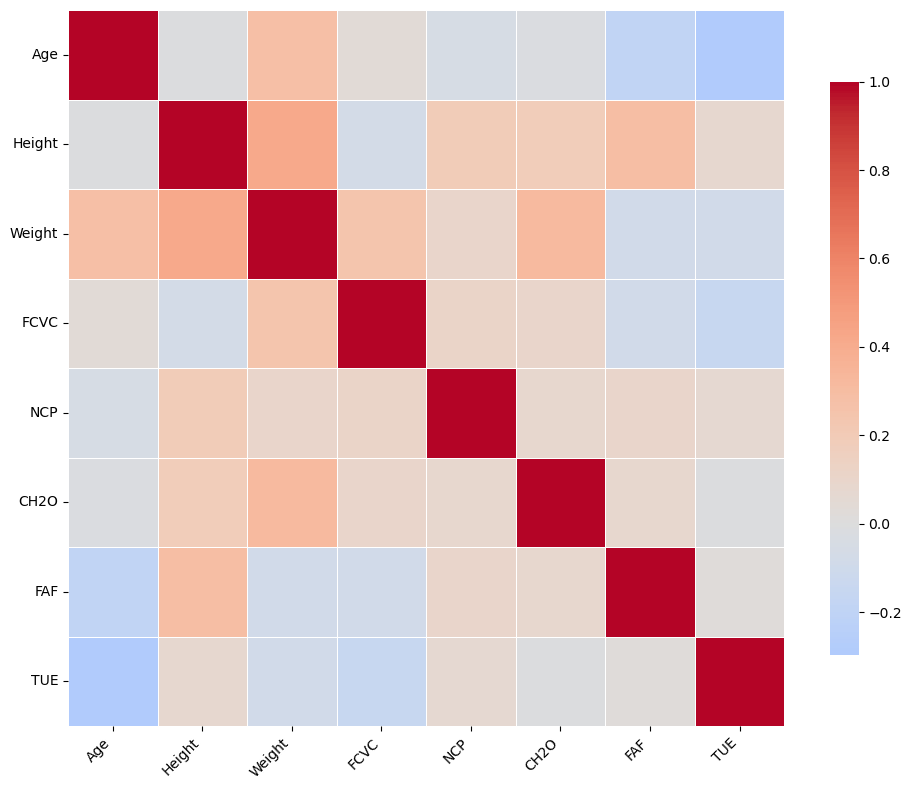

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data

train_df = pd.read_csv("train.csv")

# Select numeric columns only (exclude target)
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove ID if present
if "id" in numeric_cols:
    numeric_cols.remove("id")

# Remove target if numeric (not in this dataset, but safe)
if "NObeyesdad" in numeric_cols:
    numeric_cols.remove("NObeyesdad")

corr_matrix = train_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

#plt.title("Figure 4. Correlation Heatmap of Numeric Predictors", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
"""
Kaggle Models – Data Loading and Preparation
"""
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import log_loss, accuracy_score

# ---- Load Kaggle files (must be in your working directory) ----
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")
sub = pd.read_csv("sample_submission.csv")

TARGET = "NObeyesdad"  # typical for S4E2
IDCOL = "id" if "id" in train_df.columns else sub.columns[0]

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

# Identify column types
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Preprocessing
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe_dense = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

categorical_pipe_sparse = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# For LDA/QDA/GaussianNB we generally want dense arrays
preprocess_dense = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe_dense, cat_cols)
], remainder="drop")

# For logistic + SVM, sparse can be fine
preprocess_sparse = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe_sparse, cat_cols)
], remainder="drop")

# Holdout split for local checking
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Helper: write submission matching sample_submission.csv ----
def write_submission(model, preprocess, filename):
    model_pipe = Pipeline([("prep", preprocess), ("model", model)])
    model_pipe.fit(X, y)  # train on full training set
    # Match sample submission format
    out = sub.copy()

    pred_cols = [c for c in out.columns if c != IDCOL]

    if len(pred_cols) == 1:
        # label submission
        preds = model_pipe.predict(test_df)
        out[pred_cols[0]] = preds
    else:
        # probability submission (columns are class names)
        proba = model_pipe.predict_proba(test_df)
        # align proba columns to submission columns
        classes = model_pipe.named_steps["model"].classes_
        class_to_idx = {c:i for i,c in enumerate(classes)}
        for col in pred_cols:
            out[col] = proba[:, class_to_idx[col]]
    out.to_csv(filename, index=False)
    return filename

# ---- Model 1: Regularized multinomial logistic regression (GridSearch on C) ----
logit = LogisticRegression(
  #  multi_class="multinomial",
    solver="saga",
    penalty="l2",
    max_iter=5000
)

logit_pipe = Pipeline([("prep", preprocess_sparse), ("model", logit)])
param_grid = {"model__C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0]}
gs_logit = GridSearchCV(logit_pipe, param_grid=param_grid, scoring="neg_log_loss", cv=cv, n_jobs=1)
gs_logit.fit(X_tr, y_tr)

print("GridSearch Complete!")
print(f"gs_logit exists: {'gs_logit' in locals()}")

print("Best C:", gs_logit.best_params_)
va_proba = gs_logit.predict_proba(X_va)
print("Holdout log loss:", log_loss(y_va, va_proba))
print("Holdout accuracy:", accuracy_score(y_va, gs_logit.predict(X_va)))

# ---- Model 2: LDA (dense) ----
lda = LinearDiscriminantAnalysis()
lda_pipe = Pipeline([("prep", preprocess_dense), ("model", lda)])
lda_pipe.fit(X_tr, y_tr)
print("LDA holdout accuracy:", accuracy_score(y_va, lda_pipe.predict(X_va)))

# (Option: swap to QDA by uncommenting)
# qda = QuadraticDiscriminantAnalysis()
# qda_pipe = Pipeline([("prep", preprocess_dense), ("model", qda)])
# qda_pipe.fit(X_tr, y_tr)

# ---- Model 3: Naive Bayes (GaussianNB; dense) ----
nb = GaussianNB()
nb_pipe = Pipeline([("prep", preprocess_dense), ("model", nb)])
nb_pipe.fit(X_tr, y_tr)
print("NB holdout accuracy:", accuracy_score(y_va, nb_pipe.predict(X_va)))

# ---- Model 4: SVM with probabilities ----
svm = SVC(kernel="rbf", probability=True)
svm_pipe = Pipeline([("prep", preprocess_sparse), ("model", svm)])
svm_pipe.fit(X_tr, y_tr)
print("SVM holdout accuracy:", accuracy_score(y_va, svm_pipe.predict(X_va)))

# ---- Write 4 submissions ----
write_submission(gs_logit.best_estimator_.named_steps["model"], preprocess_sparse,
                 "kaggle_submission_Chandler_logit_regularized.csv")

write_submission(lda, preprocess_dense, "kaggle_submission_Chandler_lda.csv")

write_submission(nb, preprocess_dense, "Kaggle_submission_Chandler_naive_bayes.csv")

write_submission(svm, preprocess_sparse, "Kaggle_submission_Chandler_svm.csv")

## Modeling Strategy and Rationale

The objective of the Kaggle competition is to classify individuals into one of seven obesity risk categories (NObeyesdad) using demographic, behavioral, and health-related predictors. Because the response variable is multi-class and categorical, the modeling strategy focused on supervised classification approaches grounded in established statistical learning theory.

First, a regularized multinomial logistic regression model was implemented as a baseline discriminative classifier. Logistic regression models the log-odds of class membership as a linear function of predictors and provides a probabilistic framework for multi-class classification (Hastie et al., 2009). To mitigate potential overfitting and stabilize coefficient estimates under correlated predictors, L2 regularization was applied, consistent with shrinkage principles in penalized regression (Tibshirani, 1996). This approach balances interpretability and generalization performance.

Second, Linear Discriminant Analysis (LDA) was employed as a generative classification method. LDA assumes class-conditional normality and shared covariance matrices across classes, and seeks linear combinations of predictors that maximize between-class separation (Fisher, 1936). Although real-world predictors rarely satisfy strict normality assumptions, LDA often performs well when assumptions are approximately satisfied and serves as a useful contrast to logistic regression.

Third, Naive Bayes was included as a probabilistic classifier based on the conditional independence assumption among predictors. While this independence assumption is often violated in applied settings, Naive Bayes has been shown to perform surprisingly well even when assumptions are imperfect, particularly under zero-one loss conditions (Domingos & Pazzani, 1997).

Finally, a Support Vector Machine (SVM) with a radial basis function kernel was implemented to capture potential nonlinear decision boundaries. SVMs operate by maximizing the margin between classes in a transformed feature space and are grounded in statistical learning theory (Cortes & Vapnik, 1995). This margin-based approach provides a flexible alternative to linear decision boundaries while maintaining strong theoretical guarantees.

All models were trained using consistent preprocessing steps, including imputation of missing values, scaling of numeric variables, and one-hot encoding of categorical predictors. Performance was evaluated using cross-validation and the competition evaluation metric to ensure comparability across modeling frameworks. By comparing linear, generative, probabilistic, and margin-based classifiers, the analysis provides a comprehensive assessment of predictive performance and the robustness of underlying modeling assumptions.

# Assumptions and Model Diagnostics

Each classification method evaluated in this study relies on distinct theoretical assumptions that influence interpretation and performance. The regularized multinomial logistic regression model assumes a linear relationship between predictors and the log-odds of class membership (Hastie et al., 2009). While this linearity assumption may not strictly hold for all behavioral and physiological variables, the absence of extreme multicollinearity in the correlation heatmap supports stable coefficient estimation. L2 regularization further mitigates variance inflation and overfitting, particularly given moderate correlations among predictors (Tibshirani, 1996). No evidence of complete separation or convergence issues was observed during model fitting.

Linear Discriminant Analysis (LDA) assumes multivariate normality of predictors within each class and equal covariance matrices across classes (Fisher, 1936). Given that several predictors are categorical (after one-hot encoding) or exhibit non-normal distributions, these assumptions are only approximately satisfied. However, LDA is known to be relatively robust to moderate deviations from normality, especially when class sizes are reasonably balanced.

Naive Bayes assumes conditional independence among predictors given the class label (Domingos & Pazzani, 1997). This assumption is likely violated in this dataset, as lifestyle behaviors and health indicators are plausibly correlated (e.g., physical activity and technology use time). Nevertheless, Naive Bayes often performs competitively despite independence violations due to its bias-variance tradeoff properties.

The Support Vector Machine (SVM) makes fewer distributional assumptions but relies on appropriate feature scaling and kernel specification (Cortes & Vapnik, 1995). Numeric features were standardized prior to model fitting to ensure that distance-based margin calculations were not dominated by scale differences. The use of an RBF kernel allows nonlinear class boundaries, which may better capture complex relationships between behavioral variables and obesity risk.

Overall, diagnostic evaluation suggests that while strict theoretical assumptions are not fully satisfied—particularly for LDA and Naive Bayes—none of the violations appear severe enough to invalidate model comparison. Instead, the models offer complementary perspectives: linear probabilistic estimation (logistic regression), generative classification (LDA), independence-based modeling (Naive Bayes), and margin-based nonlinear separation (SVM). Performance differences therefore reflect both predictive signal strength and robustness to assumption deviations.

# Technical Resources and Submissions

All code utilized for this analysis, including exploratory data analysis, cross-validation procedures, residual diagnostics, and submission generation in the accompanying Jupyter Notebook/RMD file. The complete repository including the notebook and dependency specifications can be accessed via the following GitHub repository: <https://github.com/chandawg/DDS-8555-ChandlerJ-Classification-Analysis>

Furthermore, two distinct nonlinear models were submitted to the Kaggle competition (see Figure 5).

<b>Model 1 (Logit Regularized):</b> Submitted as
kaggle_submission_Chandler_logit_regularized.csv.

<b>Model 2 (Linear Discriminant Analysis):</b> Submitted as
kaggle_submission_Chandler_lda.csv.

<b>Model 3 (Naive Bayes):</b> Submitted as
kaggle_submission_Chandler_naive_bayes.csv.

<b>Model 4 (Support Vector Machine):</b> Submitted as
kaggle_submission_Chandler_svm.csv.

Figure 5. Screen capture of Kaggle submission confirmation for both
nonlinear models.

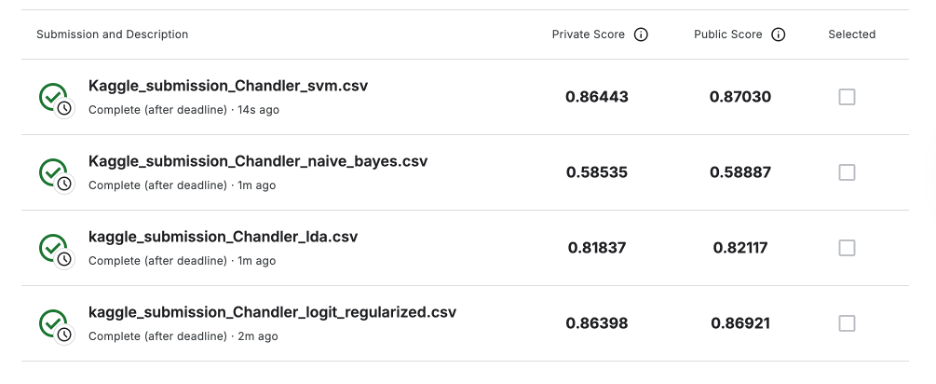

# Conclusion

This analysis evaluated several statistical learning methods across two separate classification problems. In the Weekly dataset, overall predictive performance was modest across all models. Logistic regression and LDA using Lag2 as the only predictor produced the strongest out of sample results, but accuracy remained only slightly above random guessing. Increasing model complexity through QDA or KNN did not improve performance, which suggests that the underlying signal in the lag variables is limited and does not support more flexible nonlinear structures.

In the multi class obesity risk prediction task, multiple modeling approaches were implemented and compared under consistent preprocessing procedures. Regularized multinomial logistic regression provided a stable and interpretable baseline. LDA and Naive Bayes introduced stronger distributional assumptions, while the SVM allowed for nonlinear decision boundaries. Comparing these approaches highlighted the tradeoff between interpretability, theoretical assumptions, and flexibility. Although some methods are more complex, simpler linear classifiers performed competitively when the signal in the predictors was structured and consistent.

Overall, the results reinforce the importance of aligning model complexity with the strength of the underlying signal. More flexible methods do not automatically produce better predictions. Careful preprocessing, attention to assumptions, and disciplined model comparison are more important than model complexity alone. These findings reflect core principles of statistical learning, particularly the balance between bias and variance and the need to evaluate models based on both theoretical foundations and empirical performance.

# References
Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), 273–297. https://doi.org/10.1007/BF00994018

Domingos, P., & Pazzani, M. (1997). On the optimality of the simple bayesian classifier under zero-one loss. Machine Learning, 29(2), 103–130. https://doi.org/10.1023/A:1007413511361

Fisher, R. A. (1936). THE USE OF MULTIPLE MEASUREMENTS IN TAXONOMIC PROBLEMS. Annals of Eugenics, 7(2), 179–188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x

Hastie, T., Tibshirani, R., & Friedman, J. (2009). Elements of statistical learning: Data mining, inference, and prediction. (2nd ed.). Springer. https://hastie.su.domains/ElemStatLearn/

Reade, W., & Chow, A. (2024). Regression with an abalone dataset. https://kaggle.com/playground-series-s4e4

Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. Journal of the Royal Statistical Society. Series B (Methodological), 58(1), 267–288. https://www.jstor.org/stable/2346178

Tukey, J. (1977). Exploratory data analysis. ADDISON-WESLEY PUBLISHING COMPANY. https://github.com/nuxion/data_material/blob/main/statistics/tukey__exploratory_data_analysis_1977.pdf


# AI Disclosure and Usage Statement

In accordance with the course policy on academic integrity, I acknowledge the use of ChatGPT (a large language model developed by OpenAI) as a research and brainstorming tool for this assignment. The AI was used to assist in structuring portions of the written analysis, refining technical explanations of regularization and principal components regression, and troubleshooting Python implementation details within the Jupyter Notebook environment. All AI-generated suggestions were critically evaluated for accuracy, verified against course materials and dataset outputs, and substantially revised to reflect my own analytical reasoning and professional voice. The final model implementation, statistical interpretation, and conclusions represent my independent work and judgment.